In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("praneet0327/brain-tumor-dataset")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 100M/100M [00:17<00:00, 5.87MB/s]

Extracting files...


Path to dataset files: C:\Users\91807\.cache\kagglehub\datasets\praneet0327\brain-tumor-dataset\versions\1


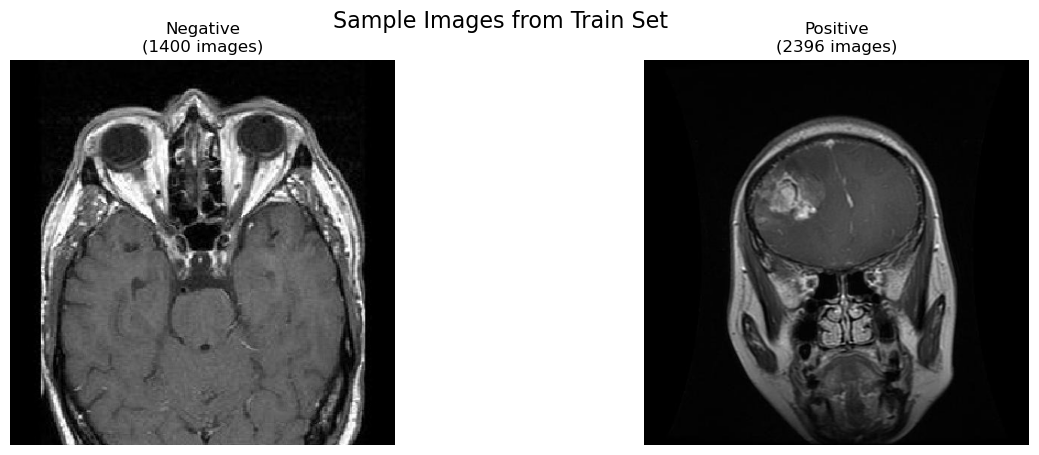

Class counts in Train Set: {'Negative': 1400, 'Positive': 2396}


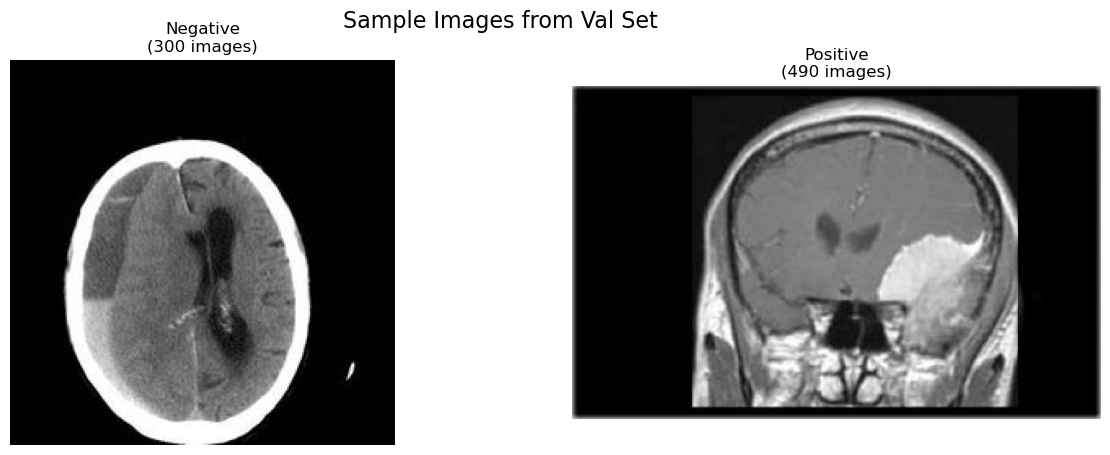

Class counts in Val Set: {'Negative': 300, 'Positive': 490}


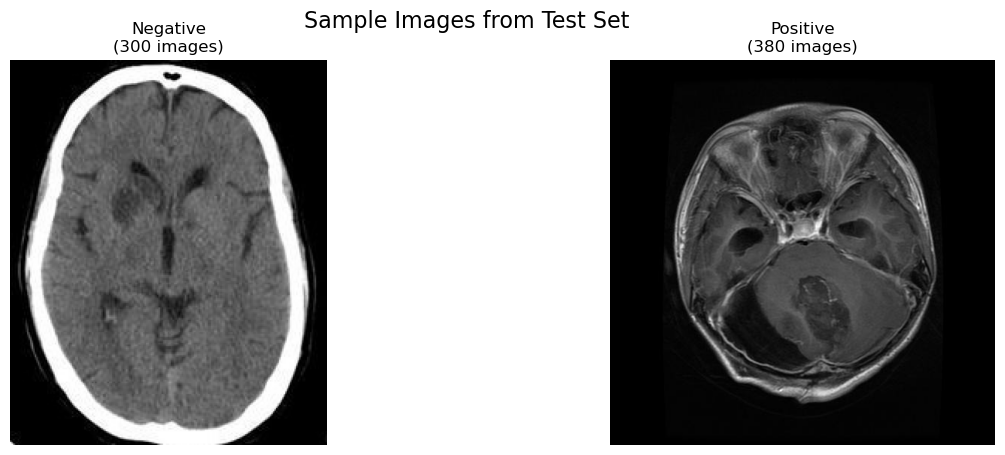

Class counts in Test Set: {'Negative': 300, 'Positive': 380}


In [3]:
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Dataset directories for train, validation, and test
base_path = r"C:\Users\91807\.cache\kagglehub\datasets\praneet0327\brain-tumor-dataset\versions\1\Brain_Tumor_Dataset"
sets = ['train', 'val', 'test']  
categories = ['Negative','Positive']  

# Loop through each set (train, val, test) to visualize data
for dataset_type in sets:
    set_path = os.path.join(base_path, dataset_type)  # Path to train/val/test
    class_counts = {}  # Dictionary to store counts per class
    
    # Initialize a figure for visualization
    fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))
    fig.suptitle(f"Sample Images from {dataset_type.capitalize()} Set", fontsize=16)
    
    for i, category in enumerate(categories):
        class_path = os.path.join(set_path, category)  # Path to the specific category
        
        # Check if the folder exists
        if not os.path.exists(class_path):
            raise FileNotFoundError(f"Class folder '{category}' not found at {class_path}")
        
        # Count the number of images in the class
        images = os.listdir(class_path)
        class_counts[category] = len(images)
        
        # Display a sample image from the class
        sample_image_path = os.path.join(class_path, images[0])
        sample_image = imread(sample_image_path)
        axes[i].imshow(sample_image)
        axes[i].set_title(f"{category}\n({len(images)} images)")
        axes[i].axis('off')
    
    plt.show()
    print(f"Class counts in {dataset_type.capitalize()} Set:", class_counts)


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = os.path.join(base_path, "train")
val_dir = os.path.join(base_path, "val")
test_dir = os.path.join(base_path, "test")

# Parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,  
    rotation_range=30,    
    width_shift_range=0.2, 
    height_shift_range=.2,  
    zoom_range=0.2,         
    horizontal_flip=True,   
    fill_mode='nearest'
)

# No augmentation for validation and testing, just normalization
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# Load data from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False 
)

Found 3796 images belonging to 2 classes.
Found 790 images belonging to 2 classes.
Found 680 images belonging to 2 classes.


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D,BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import os
import cv2
import zipfile
from tensorflow.keras.regularizers import l2

model = Sequential()

model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.1))

model.add(Dense(1, activation='sigmoid'))

callback = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=4, restore_best_weights=True)

In [6]:
model.compile(
    optimizer='adam',  
    loss='binary_crossentropy',  
    metrics=['accuracy']  
)

In [7]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 128)     3584      
                                                                 
 batch_normalization (Batch  (None, 224, 224, 128)     512       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 128)     0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 128)     147584    
                                                                 
 batch_normalization_1 (Bat  (None, 112, 112, 128)     512       
 chNormalization)                                                
                                                      

In [27]:
history = model.fit( train_generator,
    validation_data=val_generator,
    epochs=12, shuffle=True, callbacks=[callback])

Epoch 1/12
119/119 [==============================] - 734s 6s/step - loss: 8.5031 - accuracy: 0.8201 - val_loss: 15.5718 - val_accuracy: 0.6203
Epoch 2/12
119/119 [==============================] - 733s 6s/step - loss: 6.0525 - accuracy: 0.8456 - val_loss: 20.1105 - val_accuracy: 0.3772
Epoch 3/12
119/119 [==============================] - 734s 6s/step - loss: 4.4242 - accuracy: 0.8743 - val_loss: 4.2824 - val_accuracy: 0.6772
Epoch 4/12
119/119 [==============================] - 727s 6s/step - loss: 4.4290 - accuracy: 0.8633 - val_loss: 5.7189 - val_accuracy: 0.3532
Epoch 5/12
119/119 [==============================] - 902s 8s/step - loss: 3.3056 - accuracy: 0.8617 - val_loss: 2.6152 - val_accuracy: 0.8392
Epoch 6/12
119/119 [==============================] - 1044s 9s/step - loss: 2.2390 - accuracy: 0.8946 - val_loss: 1.9117 - val_accuracy: 0.8797
Epoch 7/12
119/119 [==============================] - 722s 6s/step - loss: 1.6352 - accuracy: 0.9173 - val_loss: 1.3704 - val_accuracy: 0.9

In [36]:
model.save('model_checkpoint.h5')

C:\Users\91807\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [37]:
# Save the best model after the first 12 epochs (if you haven't already done so)
model = tf.keras.models.load_model('model_checkpoint.h5')
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    'model_checkpoint.h5',  # Path to save the model
    monitor='val_loss',  # Monitor validation loss (or accuracy)
    save_best_only=True,  # Save only the best model
    save_weights_only=False,  # Save the entire model
    verbose=1
)

model = tf.keras.models.load_model('model_checkpoint.h5')

# Resume training for 5 more epochs, starting from epoch 13
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=17,  # Total epochs (12 already done, now 5 more)
    initial_epoch=12,  # Start from epoch 12 (the last completed epoch)
    shuffle=True,
    callbacks=[checkpoint_callback]
)


Epoch 13/17
119/119 [==============================] - ETA: 0s - loss: 0.6632 - accuracy: 0.9370
Epoch 13: val_loss improved from inf to 0.86003, saving model to model_checkpoint.h5
119/119 [==============================] - 731s 6s/step - loss: 0.6632 - accuracy: 0.9370 - val_loss: 0.8600 - val_accuracy: 0.8696
Epoch 14/17
119/119 [==============================] - ETA: 0s - loss: 0.6602 - accuracy: 0.9328
Epoch 14: val_loss improved from 0.86003 to 0.65445, saving model to model_checkpoint.h5
119/119 [==============================] - 717s 6s/step - loss: 0.6602 - accuracy: 0.9328 - val_loss: 0.6545 - val_accuracy: 0.9266
Epoch 15/17
119/119 [==============================] - ETA: 0s - loss: 0.5254 - accuracy: 0.9442 
Epoch 15: val_loss did not improve from 0.65445
119/119 [==============================] - 4593s 39s/step - loss: 0.5254 - accuracy: 0.9442 - val_loss: 3.0436 - val_accuracy: 0.3810
Epoch 16/17
119/119 [==============================] - ETA: 0s - loss: 1.4921 - accuracy

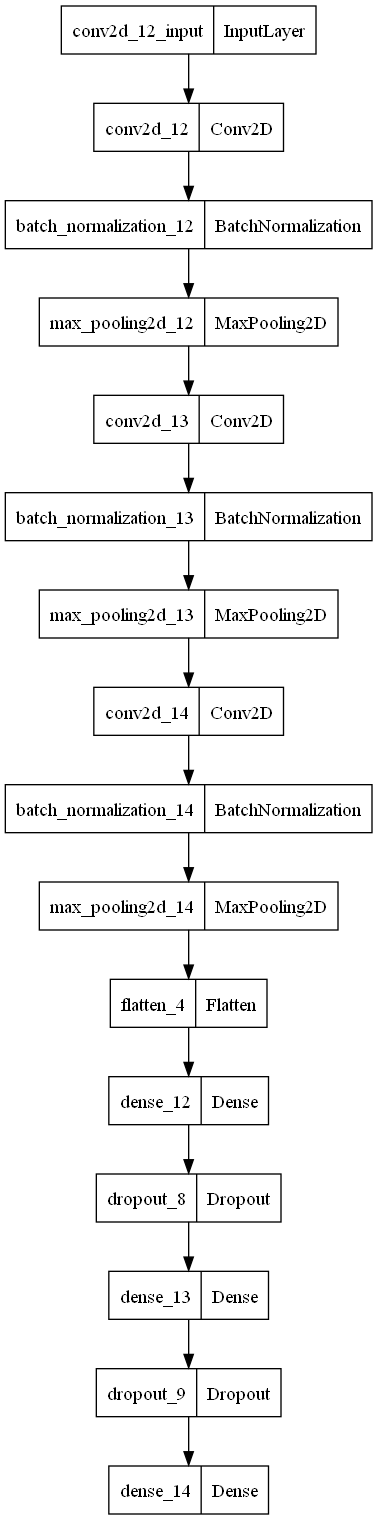

In [38]:
from keras.utils import plot_model
plot_model(model)

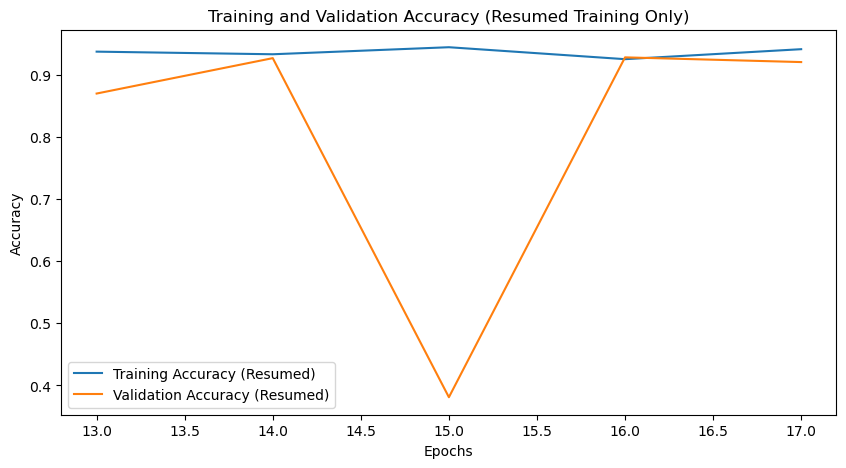

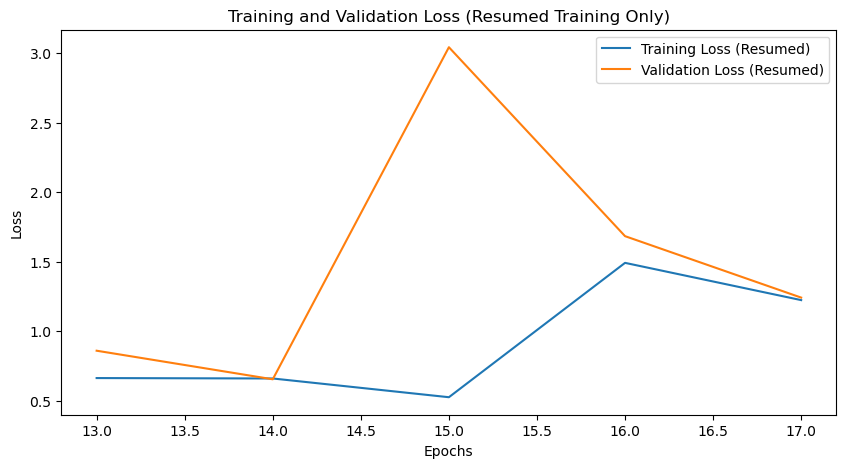

In [44]:
# Plot training and validation accuracy (Resumed Training Only)
plt.figure(figsize=(10, 5))
plt.plot(range(13, 18), history.history['accuracy'], label='Training Accuracy (Resumed)')
plt.plot(range(13, 18), history.history['val_accuracy'], label='Validation Accuracy (Resumed)')
plt.title('Training and Validation Accuracy (Resumed Training Only)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss (Resumed Training Only)
plt.figure(figsize=(10, 5))
plt.plot(range(13, 18), history.history['loss'], label='Training Loss (Resumed)')
plt.plot(range(13, 18), history.history['val_loss'], label='Validation Loss (Resumed)')
plt.title('Training and Validation Loss (Resumed Training Only)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [45]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate predictions
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()  # For binary classification
true_classes = test_generator.classes  # True labels
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))


22/22 [==============================] - 23s 1s/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.92      0.86       300
    Positive       0.93      0.84      0.88       380

    accuracy                           0.87       680
   macro avg       0.87      0.88      0.87       680
weighted avg       0.88      0.87      0.87       680



In [46]:
model.save('updated_model.h5')

C:\Users\91807\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

# Load pre-trained MobileNetV2
base_model = MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet')

# Freeze the base model
base_model.trainable = False

# Ensure BatchNormalization layers are in inference mode
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Build the model
model_1 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),  # Fully connected layer
    Dropout(0.3),  # Regularization
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model_1.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Visualize the model architecture (optional, useful for debugging)
plot_model(model_1, to_file='model.png', show_shapes=True)

# Early stopping
callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model_1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[callback]
)

Epoch 1/10
119/119 [==============================] - 88s 725ms/step - loss: 0.2374 - accuracy: 0.9128 - val_loss: 0.2987 - val_accuracy: 0.8810
Epoch 2/10
119/119 [==============================] - 82s 689ms/step - loss: 0.1166 - accuracy: 0.9629 - val_loss: 0.2685 - val_accuracy: 0.9000
Epoch 3/10
119/119 [==============================] - 80s 668ms/step - loss: 0.1061 - accuracy: 0.9673 - val_loss: 0.2115 - val_accuracy: 0.9165
Epoch 4/10
119/119 [==============================] - 81s 681ms/step - loss: 0.0926 - accuracy: 0.9702 - val_loss: 0.2147 - val_accuracy: 0.9152
Epoch 5/10
119/119 [==============================] - 80s 672ms/step - loss: 0.0859 - accuracy: 0.9726 - val_loss: 0.2271 - val_accuracy: 0.9114
Epoch 6/10
119/119 [==============================] - 79s 665ms/step - loss: 0.0760 - accuracy: 0.9721 - val_loss: 0.2073 - val_accuracy: 0.9152
Epoch 7/10
119/119 [==============================] - 80s 670ms/step - loss: 0.0744 - accuracy: 0.9734 - val_loss: 0.1860 - val_ac

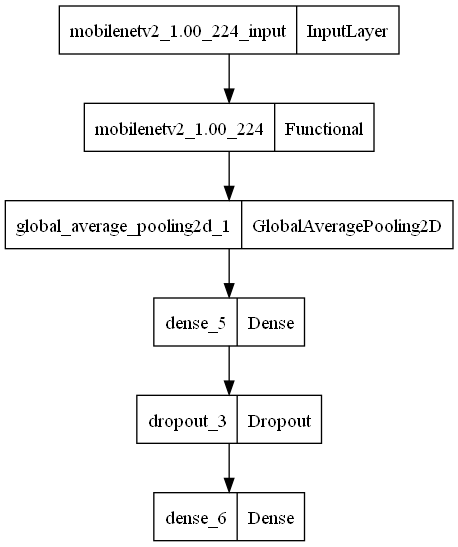

In [13]:
plot_model(model_1)

In [14]:
model_1.save('mobilevnet.h5')

C:\Users\91807\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
